# 02 — EDA



Combined into one notebook for convenience. Two unrelated datasets, analyzed separately:

- **Part A** — `cars` (the 752,900-row scraped listings dataset)

- **Part B** — `used_cars` (the ~97,600-row UK used car listings dataset)



**Note:** Part B's load cell points at a file literally named `cars_clean.csv`, which is a different file from the one Part A loads — that name was set by an early run of `01_cleaning.ipynb`, before the two datasets' outputs were split into `used_cars_clean.csv` / `cars_clean.csv`. Nothing in this notebook depends on both parts running in the same session, but worth renaming that file on your end so the path actually says what it is.

## Part A — EDA: `cars` dataset



Exploratory analysis of `../data/processed/cars_clean.csv` — the 752,900-row scraped listings dataset cleaned in `01_cleaning_both.ipynb` (0 remaining nulls after the Part 7 fill-in).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("../data/processed/cars_clean.csv", low_memory=False)
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/cars_clean.csv'

## Part 1 — Numeric distributions

count    7.529000e+05
mean     3.253072e+04
std      2.368223e+04
min      5.000000e+02
25%      1.959500e+04
50%      2.799000e+04
75%      3.948800e+04
max      2.250000e+06
Name: price, dtype: float64

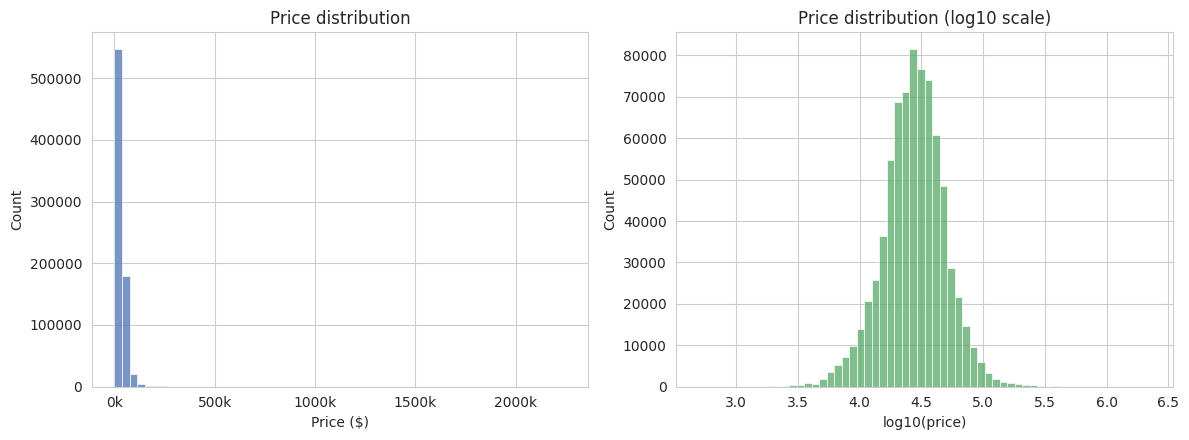

In [ ]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['price'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

sns.histplot(np.log10(df['price']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('Price distribution (log10 scale)')
axes[1].set_xlabel('log10(price)')
plt.tight_layout()
plt.show()

**Insight:** median listing price is **$27,990**, but the mean ($32,531) sits well above it — a classic right-skewed distribution, pulled up by the exotic tail discussed in cleaning. On a log10 scale the distribution looks close to normal, which is the usual signal that price should be log-transformed before feeding it into any linear model later.

count    752900.000000
mean       2017.790101
std           5.114157
min        1915.000000
25%        2016.000000
50%        2019.000000
75%        2021.000000
max        2024.000000
Name: year, dtype: float64

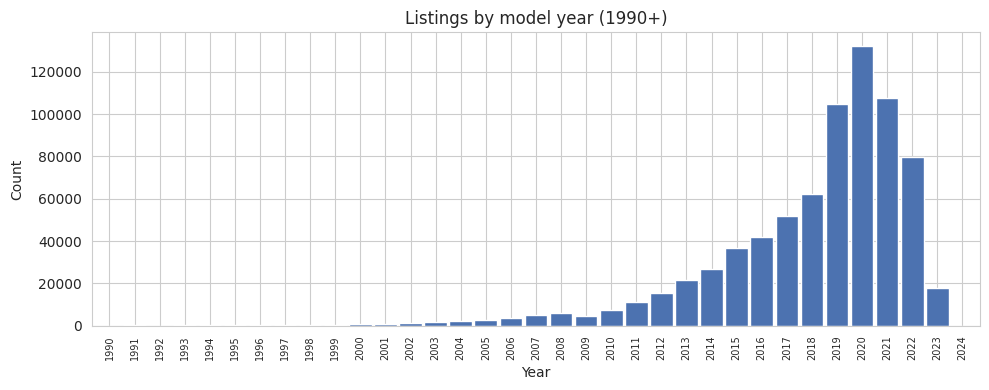

In [ ]:
print(df['year'].describe())

plt.figure(figsize=(10, 4))
df[df['year'] >= 1990]['year'].value_counts().sort_index().plot(kind='bar', color='#4C72B0', width=0.9)
plt.title('Listings by model year (1990+)')
plt.xlabel('Year'); plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

**Insight:** the inventory is overwhelmingly late-model — 75% of listings are 2016 or newer — which matches a used-car marketplace turning over recent trade-ins rather than a classic-car site. The pre-1990 listings flagged during cleaning are real but vanishingly rare next to this (not visible on this axis).

count    7.529000e+05
mean     5.578130e+04
std      4.349905e+04
min      0.000000e+00
25%      2.330000e+04
50%      4.560500e+04
75%      7.835800e+04
max      1.119067e+06
Name: mileage, dtype: float64

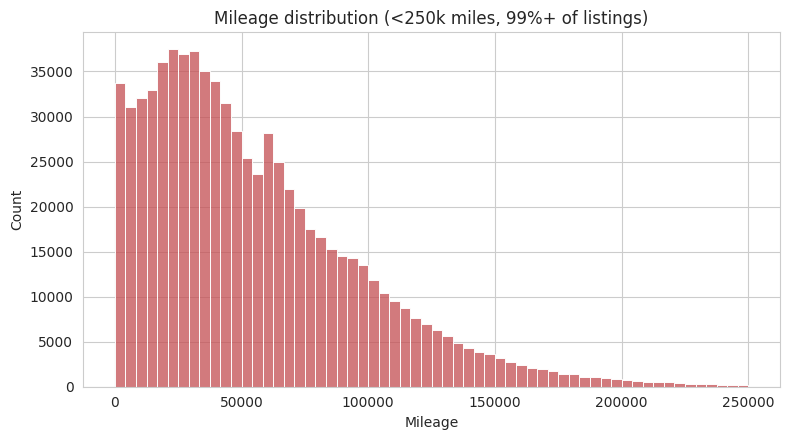

In [ ]:
print(df['mileage'].describe())

plt.figure(figsize=(8, 4.5))
sns.histplot(df[df['mileage'] < 250000]['mileage'], bins=60, color='#C44E52')
plt.title('Mileage distribution (<250k miles, 99%+ of listings)')
plt.xlabel('Mileage')
plt.tight_layout()
plt.show()

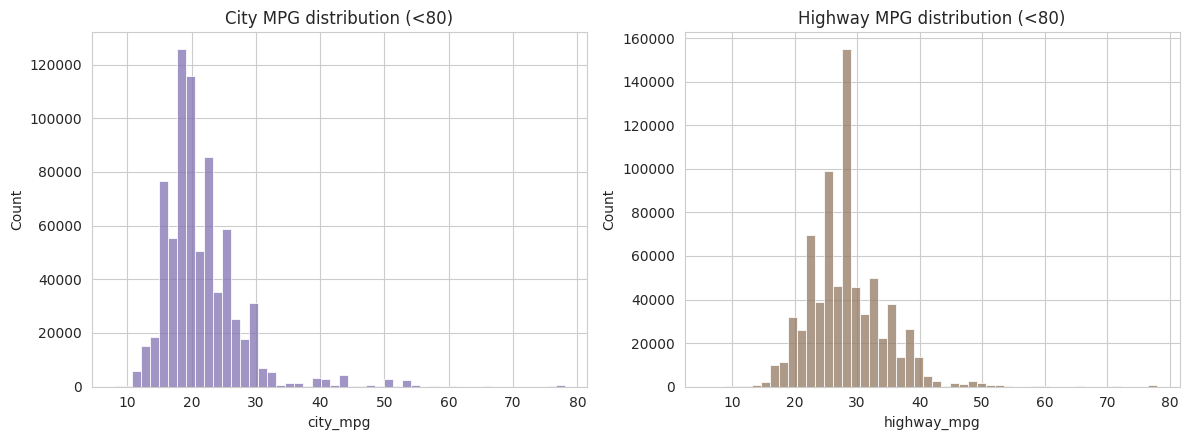

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df[df['city_mpg'] < 80]['city_mpg'], bins=50, ax=axes[0], color='#8172B2')
axes[0].set_title('City MPG distribution (<80)')
sns.histplot(df[df['highway_mpg'] < 80]['highway_mpg'], bins=50, ax=axes[1], color='#937860')
axes[1].set_title('Highway MPG distribution (<80)')
plt.tight_layout()
plt.show()

## Part 2 — Categorical distributions

manufacturer
Ford             78849
Toyota           59152
Chevrolet        55481
Nissan           47806
Jeep             41191
Mercedes-Benz    40461
Honda            37263
BMW              37074
Kia              34510
GMC              29176
Dodge            24763
Subaru           24365
Volkswagen       24288
Hyundai          22056
Lexus            20906
Name: count, dtype: int64

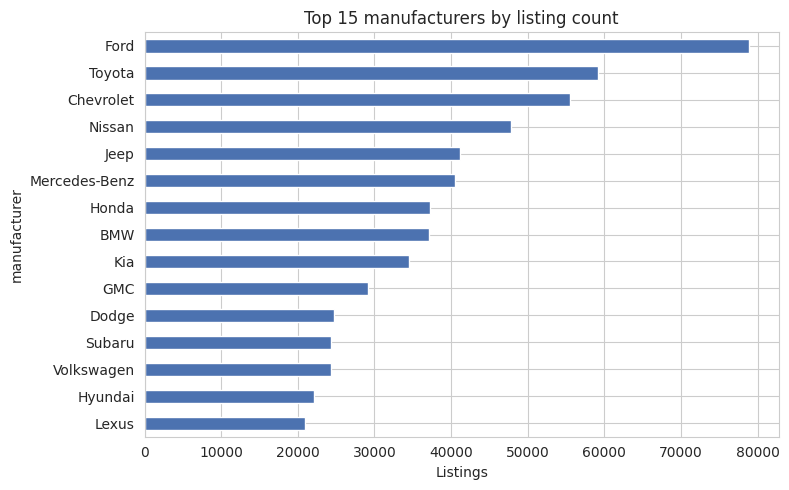

In [ ]:
top_makes = df['manufacturer'].value_counts().head(15)
print(top_makes)

plt.figure(figsize=(8, 5))
top_makes.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 manufacturers by listing count')
plt.xlabel('Listings')
plt.tight_layout()
plt.show()

fuel_type
Gasoline          637352
Diesel             29098
Hybrid             29002
Unknown            22184
Flex Fuel          18991
Electric           16119
Plug-In Hybrid       121
Natural Gas           30
Hydrogen               3
Name: count, dtype: int64

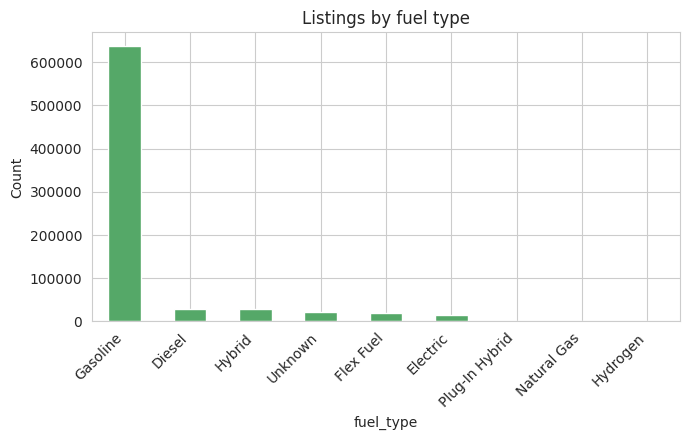

In [ ]:
fuel_counts = df['fuel_type'].value_counts()
print(fuel_counts)

plt.figure(figsize=(7, 4.5))
fuel_counts.plot(kind='bar', color='#55A868')
plt.title('Listings by fuel type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** gasoline still accounts for ~85% of listings. Electrified powertrains (Hybrid + Plug-In Hybrid + Electric) sit around 6% combined — small, but non-trivial, and worth keeping as its own segment rather than lumping into "other."

transmission
6-Speed Automatic                    146971
8-Speed Automatic                    137960
Automatic CVT                        107286
Automatic                             95925
9-Speed Automatic                     60408
10-Speed Automatic                    39645
5-Speed Automatic                     22885
7-Speed Automatic                     18863
7-Speed Automatic with Auto-Shift      15227
6-Speed Manual                        13747
Name: count, dtype: int64

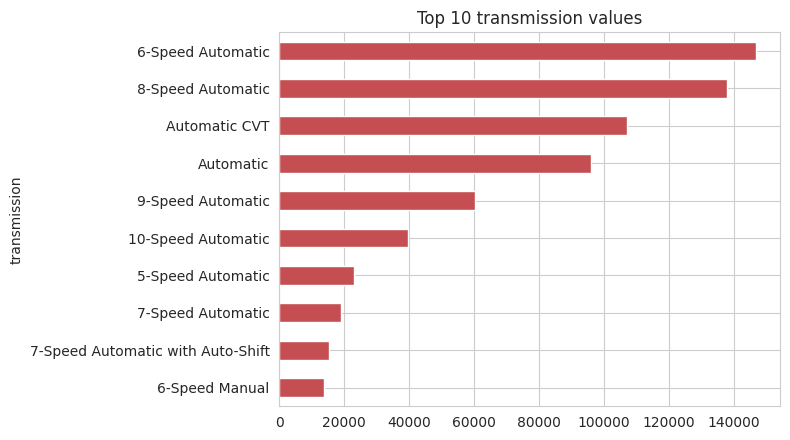

In [ ]:
trans_counts = df['transmission'].value_counts().head(10)
print(trans_counts)

plt.figure(figsize=(8, 4.5))
trans_counts.sort_values().plot(kind='barh', color='#C44E52')
plt.title('Top 10 transmission values')
plt.tight_layout()
plt.show()

drivetrain
Front-Wheel Drive    244904
All-Wheel Drive      231336
Four-Wheel Drive     157451
Rear-Wheel Drive      98208
Unknown               21001
Name: count, dtype: int64

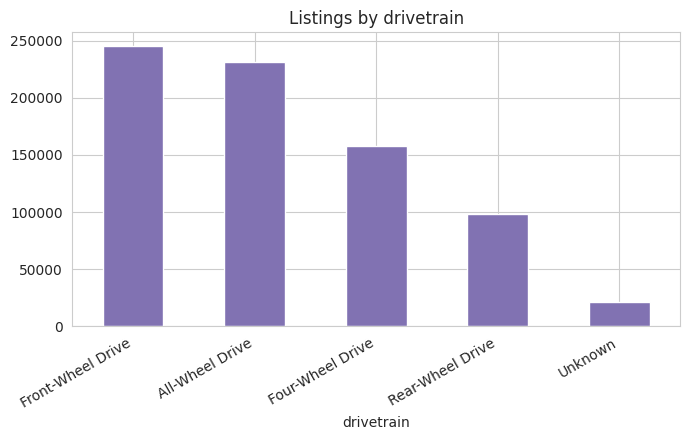

In [ ]:
dt_counts = df['drivetrain'].value_counts()
print(dt_counts)

plt.figure(figsize=(7, 4.5))
dt_counts.plot(kind='bar', color='#8172B2')
plt.title('Listings by drivetrain')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Part 3 — Price relationships

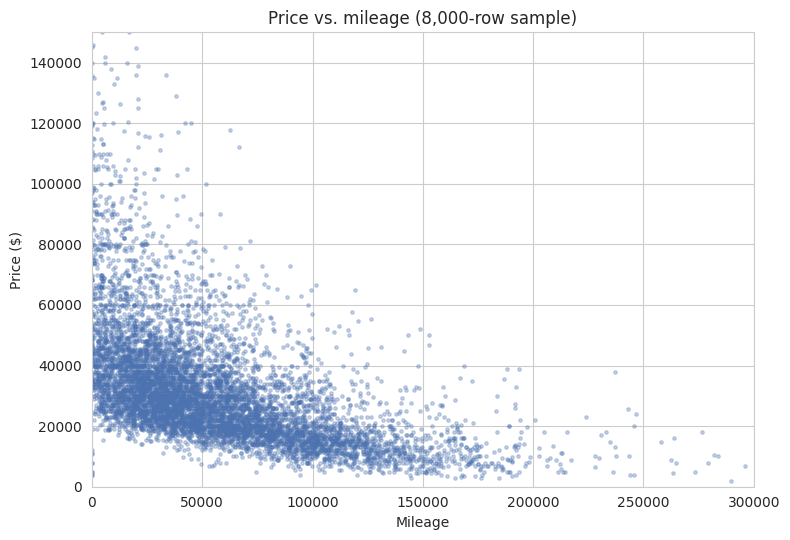

Correlation price vs mileage: -0.449

In [ ]:
sample = df.sample(8000, random_state=42)
plt.figure(figsize=(8, 5.5))
plt.scatter(sample['mileage'], sample['price'], s=6, alpha=0.3, color='#4C72B0')
plt.xlim(0, 300000)
plt.ylim(0, 150000)
plt.title('Price vs. mileage (8,000-row sample)')
plt.xlabel('Mileage'); plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

print("Correlation price vs mileage:", df['price'].corr(df['mileage']).round(3))

**Insight:** a moderate negative correlation (-0.45) — mileage explains part of price but far from all of it, which makes sense once make/model/year/condition all vary too. The band structure in the scatter (rows of points at round mileage/price values) reflects dealer pricing conventions, not a data issue.

year
2000     9945.0
2001     9323.5
2002     9999.0
2003     9988.5
2004     9989.0
2005     8999.0
2006     9600.0
2007     9991.0
2008     9997.0
2009     9999.0
2010    10995.0
2011    12347.0
2012    12998.0
2013    14495.0
2014    15988.0
2015    17995.0
2016    19998.0
2017    22824.0
2018    25989.0
2019    29348.0
2020    31478.5
2021    36950.0
2022    43970.0
2023    49989.0
2024    58420.0
Name: price, dtype: float64

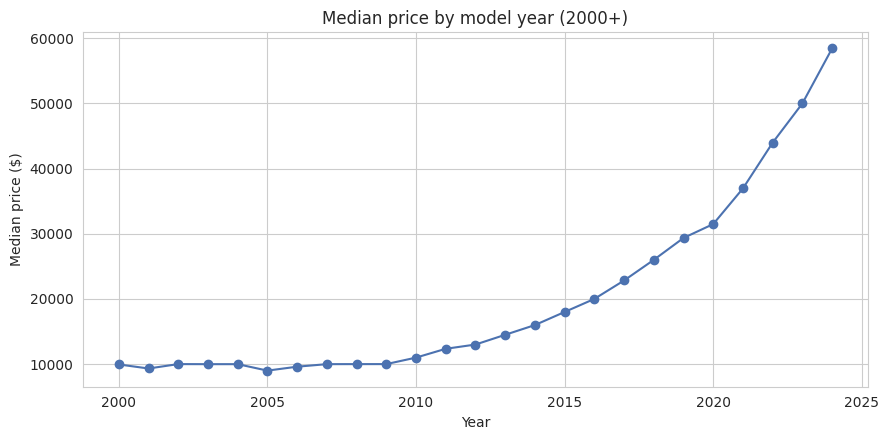

In [ ]:
med_by_year = df[df['year'] >= 2000].groupby('year')['price'].median()
print(med_by_year)

plt.figure(figsize=(9, 4.5))
med_by_year.plot(kind='line', marker='o', color='#4C72B0')
plt.title('Median price by model year (2000+)')
plt.xlabel('Year'); plt.ylabel('Median price ($)')
plt.tight_layout()
plt.show()

fuel_type
Diesel            52924.0
Electric          40817.0
Plug-In Hybrid    38500.0
Unknown           32499.5
Hybrid            31379.5
Gasoline          26999.0
Natural Gas       18998.5
Hydrogen          17899.0
Flex Fuel         17795.0
Name: price, dtype: float64

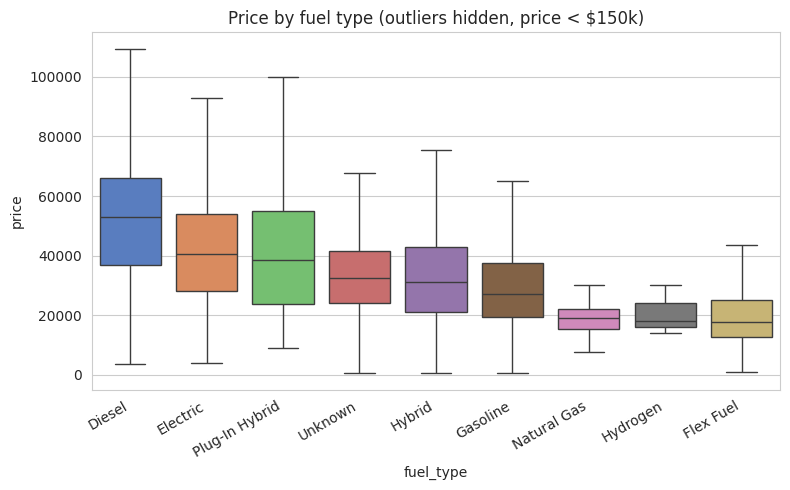

In [ ]:
print(df.groupby('fuel_type')['price'].median().sort_values(ascending=False))

plt.figure(figsize=(8, 5))
order = df.groupby('fuel_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] < 150000], x='fuel_type', y='price', order=order, showfliers=False)
plt.title('Price by fuel type (outliers hidden, price < $150k)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Diesel has the highest median price — mostly heavy-duty trucks, which command a premium regardless of fuel type. Electric and Plug-In Hybrid rank next, consistent with EVs skewing toward newer, higher-trim vehicles. Flex Fuel and Natural Gas sit at the bottom, which tracks with those being older, higher-mileage fleet-type vehicles rather than a fuel-type price effect on its own.

drivetrain
Four-Wheel Drive     38000.0
Unknown              36991.0
Rear-Wheel Drive     30998.0
All-Wheel Drive      30970.0
Front-Wheel Drive    20501.0
Name: price, dtype: float64

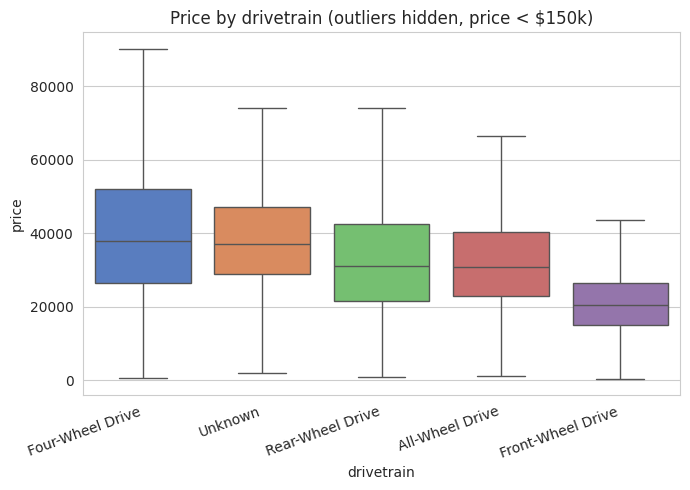

In [ ]:
print(df.groupby('drivetrain')['price'].median().sort_values(ascending=False))

plt.figure(figsize=(7, 5))
order2 = df.groupby('drivetrain')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] < 150000], x='drivetrain', y='price', order=order2, showfliers=False)
plt.title('Price by drivetrain (outliers hidden, price < $150k)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

manufacturer
Hyundai          20395.0
Kia              20998.0
Nissan           22400.0
Volkswagen       22994.0
Dodge            23247.0
Honda            24998.0
Subaru           25597.0
Chevrolet        26950.0
Jeep             27847.0
Toyota           28990.0
Ford             29459.0
BMW              33451.0
Lexus            34500.0
GMC              35592.5
Mercedes-Benz    39795.0
Name: price, dtype: float64

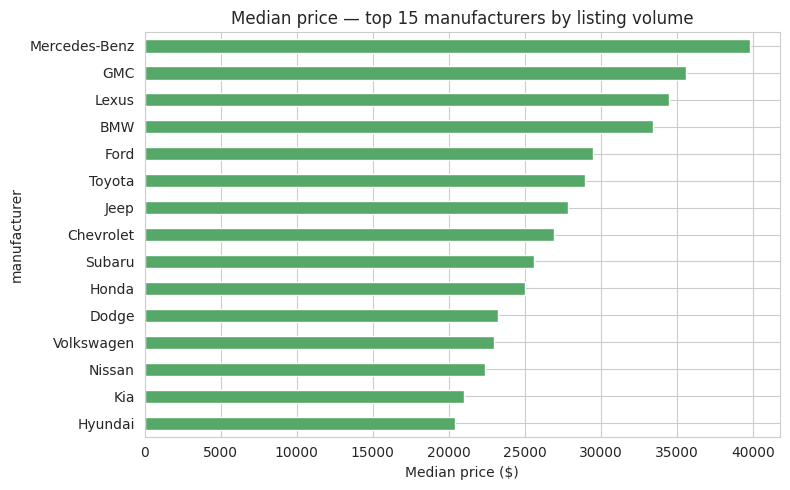

In [ ]:
top15 = df['manufacturer'].value_counts().head(15).index
avg_price = df[df['manufacturer'].isin(top15)].groupby('manufacturer')['price'].median().sort_values()
print(avg_price)

plt.figure(figsize=(8, 5))
avg_price.plot(kind='barh', color='#55A868')
plt.title('Median price — top 15 manufacturers by listing volume')
plt.xlabel('Median price ($)')
plt.tight_layout()
plt.show()

## Part 4 — Correlation across numeric fields

                    year  mileage  city_mpg  highway_mpg  seller_rating  \
year                1.00    -0.53      0.10         0.04           0.09   
mileage            -0.53     1.00     -0.07        -0.01          -0.10   
city_mpg            0.10    -0.07      1.00         0.85           0.03   
highway_mpg         0.04    -0.01      0.85         1.00           0.02   
seller_rating       0.09    -0.10      0.03         0.02           1.00   
driver_rating       0.11    -0.10      0.02         0.02           0.24   
driver_reviews_num -0.09     0.21     -0.05        -0.03          -0.06   
price_drop          0.04    -0.10     -0.04        -0.03           0.00   
price               0.27    -0.45     -0.22        -0.13           0.07   

                    driver_rating  driver_reviews_num  price_drop  price  
year                         0.11                -0.09        0.04   0.27  
mileage                     -0.10                 0.21       -0.10  -0.45  
city_mpg              

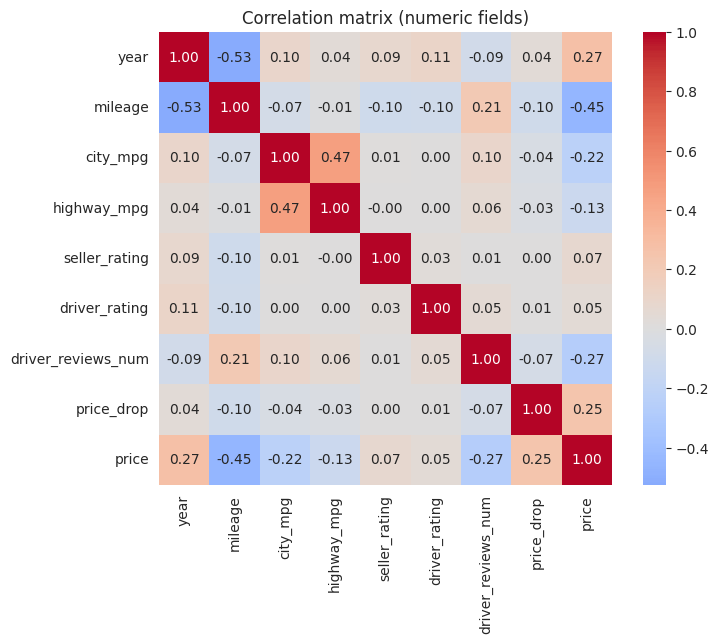

In [ ]:
num_cols = ['year', 'mileage', 'city_mpg', 'highway_mpg', 'seller_rating', 'driver_rating',
            'driver_reviews_num', 'price_drop', 'price']
corr = df[num_cols].corr()
print(corr.round(2))

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix (numeric fields)')
plt.tight_layout()
plt.show()

**Insight:** no numeric field is a strong solo predictor of `price` — `mileage` (-0.45) and `year` (0.27) are the strongest, both unsurprising. `city_mpg`/`highway_mpg` are (expectedly) highly correlated with each other (0.85), so a model would only need one of them, not both. `seller_rating` and `driver_rating` barely move with price at all, suggesting rating fields say more about the seller/experience than the vehicle.

## Key takeaways



- Price is right-skewed (median $27,990, mean $32,531) — model it on a log scale.

- Inventory skews late-model: 75% of listings are 2016+.

- Mileage and year are the strongest numeric drivers of price (-0.45 / 0.27); nothing else numeric comes close.

- Diesel and Electric/PHEV carry the highest median prices; Flex Fuel and Natural Gas the lowest — largely a vehicle-age/segment effect rather than the fuel type itself.

- `city_mpg` and `highway_mpg` are near-collinear (0.85) — keep one for modeling, not both.

- `accidents_or_damage == 'No'` listings have a meaningfully higher median price ($29,991) than `'Yes'` ($21,900), so the flag is doing real work even with ~3% of it filled as `'Unknown'`.

## Part B — EDA: `used_cars` dataset (UK used car listings)



`01_cleaning.ipynb` already started this analysis (Parts 5–7: price distribution, an IQR outlier summary, a correlation matrix, and three price-relationship scatter plots) before explicitly deferring the rest here — its own notes flag "distributions by brand" and "interaction effects" as the next step. This section keeps everything it already found and builds out from there.



Source: the `used_cars`-derived cleaned file produced by the cleaning notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

## Load & overview

In [ ]:
df = pd.read_csv("../data/processed/used_cars_clean.csv", low_memory=False)

print(df.shape)
df.head()

(97632, 12)


   model  year  price transmission  mileage fuelType  tax   mpg  engineSize  \
0  T-Roc  2019  25000    Automatic    13904   Diesel  145  49.6         2.0   
1  T-Roc  2019  26883    Automatic     4562   Diesel  145  49.6         2.0   
2  T-Roc  2019  20000       Manual     7414   Diesel  145  50.4         2.0   
3  T-Roc  2019  33492    Automatic     4825   Petrol  145  32.5         2.0   
4  T-Roc  2019  22900    Semi-Auto     6500   Petrol  150  39.8         1.5   

         Make  age  price_log  
0  Volkswagen    7  10.126671  
1  Volkswagen    7  10.199287  
2  Volkswagen    7   9.903538  
3  Volkswagen    7  10.419092  
4  Volkswagen    7  10.038936  

In [ ]:
df.describe(include='all').T

                count unique     top   freq          mean           std  \
model           97632    194  Fiesta   6508           NaN           NaN   
year          97632.0    NaN     NaN    NaN   2017.066884      2.107995   
price         97632.0    NaN     NaN    NaN   16766.21327   9861.812255   
transmission    97632      4  Manual  55496           NaN           NaN   
mileage       97632.0    NaN     NaN    NaN  23222.425506  21062.476205   
fuelType        97632      5  Petrol  53978           NaN           NaN   
tax           97632.0    NaN     NaN    NaN    120.156352      63.32627   
mpg           97632.0    NaN     NaN    NaN      55.04063     13.603719   
engineSize    97632.0    NaN     NaN    NaN      1.669201      0.552223   
Make            97632      9    Ford  17810           NaN           NaN   
age           97632.0    NaN     NaN    NaN      8.933116      2.107995   
price_log     97632.0    NaN     NaN    NaN      9.584029      0.534818   

                   min  

In [ ]:
CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']

### Part 1 — Target variable: price distribution



Skew: 2.36236297155461


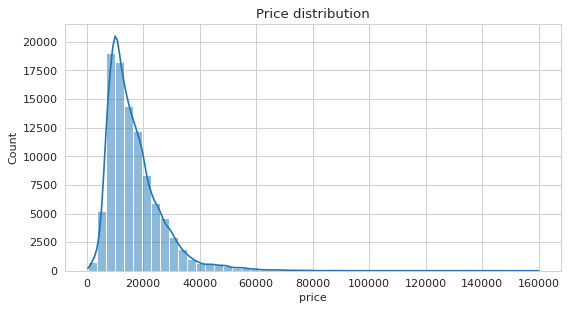

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()
print("Skew:", df['price'].skew())

**Insight:** skewness ≈ 2.36 — strongly right-skewed. Most vehicles cluster in the lower-to-mid price range, with a long tail of expensive cars pulling the mean well above the median. A log transform is the standard fix.

In [ ]:
df['price_log'] = np.log1p(df['price'])

Skew: -0.07545483377572083


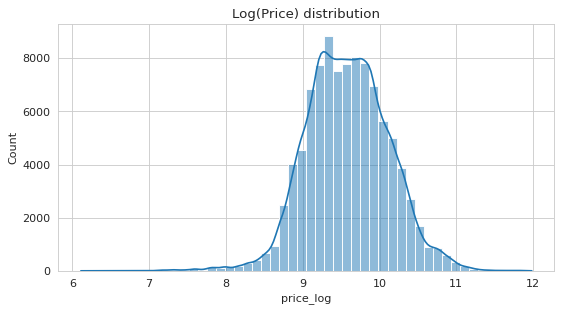

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Log(Price) distribution')
plt.show()
print("Skew:", df['price_log'].skew())

**Insight:** skew drops from 2.36 to ≈ −0.08 — close enough to symmetric that `price_log` is the better modeling target. Keeping `price` around too for interpretability.

### Part 2 — Outlier summary (documentation, not further filtering)



In [ ]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            'column': col,
            'skew': round(df[col].skew(), 2),
            'lower_fence': round(lower, 1),
            'upper_fence': round(upper, 1),
            'outliers': count,
            'pct': round(count/len(df)*100, 2)
        })
    return pd.DataFrame(rows)

iqr_outlier_summary(df, ['price_log', 'mileage', 'tax', 'mpg', 'engineSize', 'age'])

       column  skew  lower_fence  upper_fence  outliers    pct
0   price_log -0.08          8.1         11.0      1031   1.06
1     mileage  1.78     -29555.6      69733.4      3836   3.93
2         tax  0.04         95.0        175.0     28550  29.24
3         mpg  2.61         23.6         86.4       853   0.87
4  engineSize  1.41         -0.0          3.2       648   0.66
5         age  1.81          2.5         14.5      1732   1.77

**Insight:** `tax`'s high IQR-outlier rate is a banding artifact (UK vehicle tax sits in discrete government bands tied to emissions, not a smooth distribution), not a real data quality issue — it may behave more like an ordinal category than a continuous number when encoded as a feature later.

### Part 3 — Correlations & price relationships


Text(0.5, 1.0, 'Correlation matrix — numeric features')

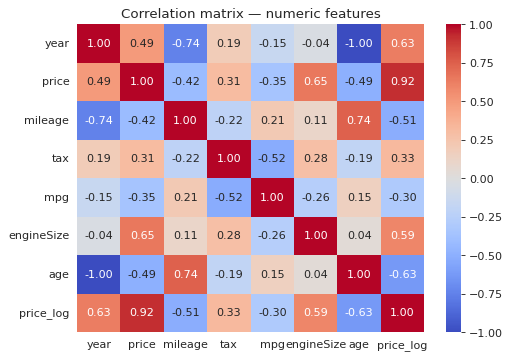

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix — numeric features')
plt.show()

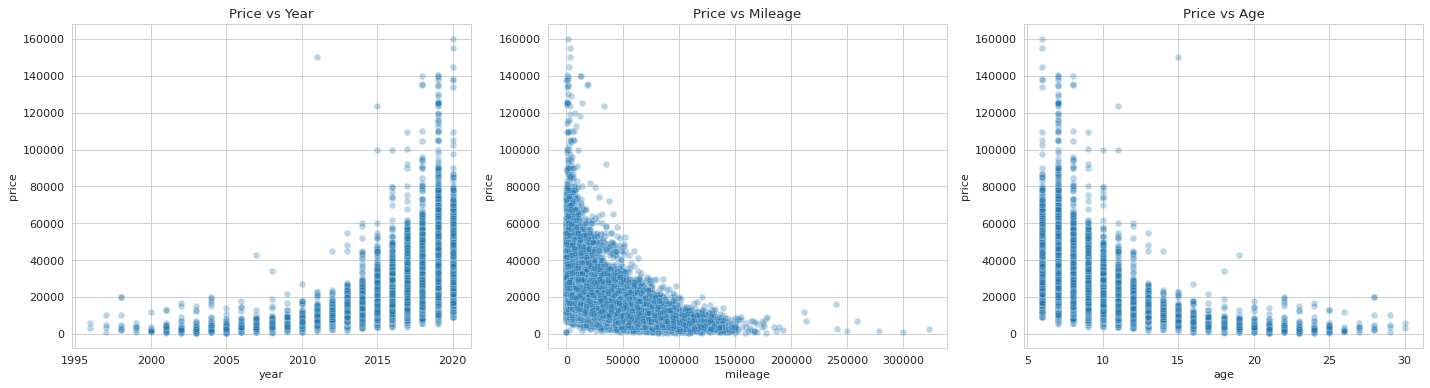

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs Year')
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3, ax=axes[1])
axes[1].set_title('Price vs Mileage')
sns.scatterplot(data=df, x='age', y='price', alpha=0.3, ax=axes[2])
axes[2].set_title('Price vs Age')
plt.tight_layout()
plt.show()

**Insight:** price generally decreases as age increases, as expected — but newer vehicles show a much wider spread of prices than older ones. That spread means `age` alone won't get you far in a price model; `Make`, `model`, `mileage`, and `engineSize` are doing a lot of the remaining explanatory work — which is exactly what the rest of this notebook digs into.

## Part 4 — Categorical composition 

What the dataset is actually made of, before looking at how each category relates to price.

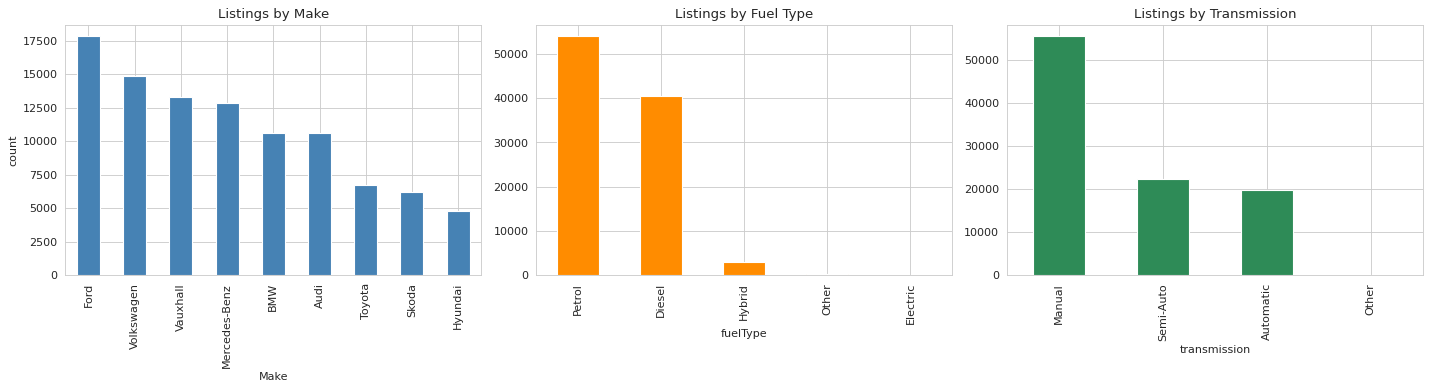

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

df['Make'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Listings by Make')
axes[0].set_ylabel('count')

df['fuelType'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Listings by Fuel Type')

df['transmission'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Listings by Transmission')

plt.tight_layout()
plt.show()

In [ ]:
print("Unique models:", df['model'].nunique())
df['model'].value_counts().head(15)

Unique models: 194


model
Fiesta      6508
Golf        4797
Focus       4555
C Class     3694
Corsa       3285
Polo        3244
Astra       2655
A Class     2471
3 Series    2426
Kuga        2208
Yaris       2117
Mokka X     2111
1 Series    1962
Aygo        1940
E Class     1928
Name: count, dtype: int64

**Insight:** Ford, Volkswagen, and Vauxhall dominate the listing volume; Electric is barely represented (3 rows) and `Other` fuel/transmission categories are vanishingly small — both are candidates to fold into a broader "Other" bucket for modeling rather than dummy-encoding as their own category. Manual is the single largest transmission group but doesn't have an outright majority.

### Part 5 — Price by category 
The "distributions by brand" analysis `01_cleaning.ipynb` flagged as a next step.

([0, 1, 2, 3, 4, 5, 6, 7, 8], [Text(0, 0, 'Mercedes-Benz'), Text(1, 0, 'BMW'), Text(2, 0, 'Audi'), Text(3, 0, 'Volkswagen'), Text(4, 0, 'Skoda'), Text(5, 0, 'Hyundai'), Text(6, 0, 'Ford'), Text(7, 0, 'Toyota'), Text(8, 0, 'Vauxhall')])

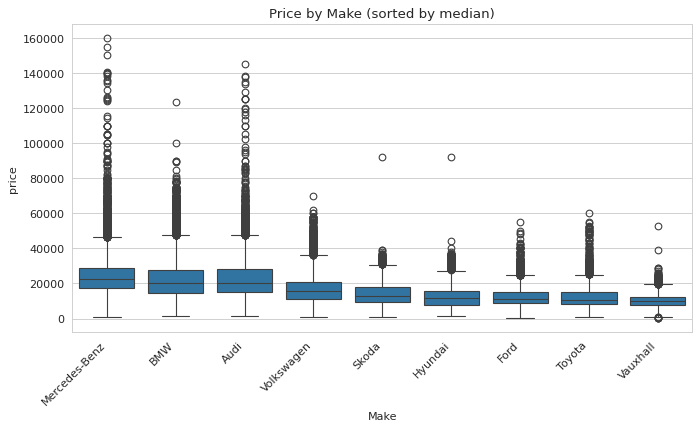

In [ ]:
order = df.groupby('Make')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Make', y='price', order=order)
plt.title('Price by Make (sorted by median)')
plt.xticks(rotation=45, ha='right')
plt.show()

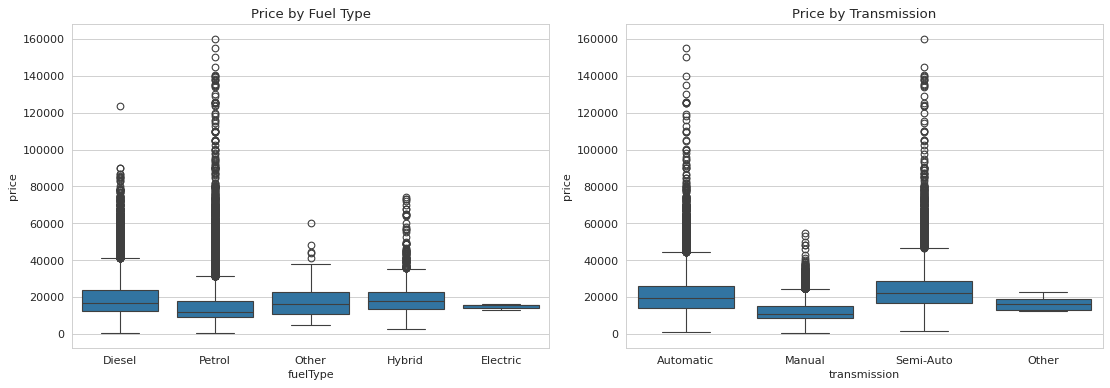

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='fuelType', y='price', ax=axes[0])
axes[0].set_title('Price by Fuel Type')
sns.boxplot(data=df, x='transmission', y='price', ax=axes[1])
axes[1].set_title('Price by Transmission')
plt.tight_layout()
plt.show()

**Insight:** Mercedes-Benz, Audi, and BMW carry a visibly higher median price and wider spread than the volume brands (Ford, Vauxhall) — `Make` alone captures a meaningful price signal before `mileage`/`age` even enter the picture. Automatic and Semi-Auto listings skew higher-priced than Manual, though that's confounded with `Make` (premium brands lean toward automatic transmissions) rather than a standalone transmission effect.

### Part 6 — Remaining numeric distributions 

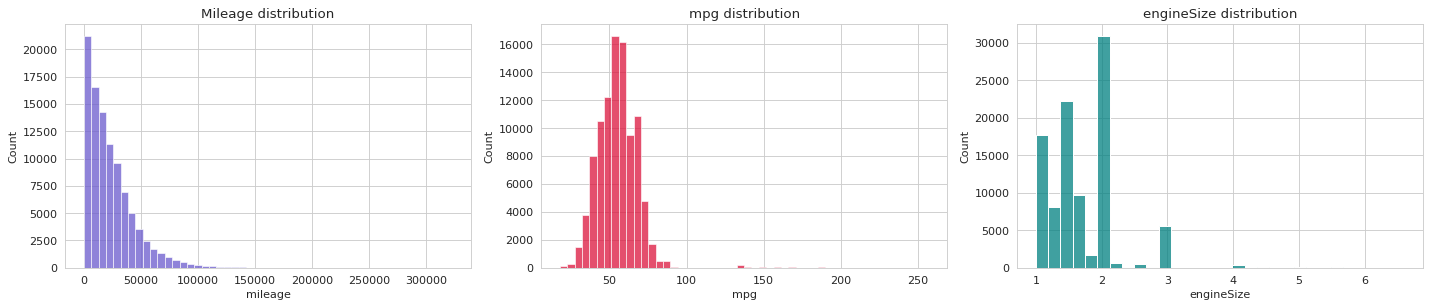

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
sns.histplot(df['mileage'], bins=50, ax=axes[0], color='slateblue')
axes[0].set_title('Mileage distribution')
sns.histplot(df['mpg'], bins=50, ax=axes[1], color='crimson')
axes[1].set_title('mpg distribution')
sns.histplot(df['engineSize'], bins=30, ax=axes[2], color='teal')
axes[2].set_title('engineSize distribution')
plt.tight_layout()
plt.show()

**Insight:** `engineSize` is effectively discrete/multimodal (cars are sold in a handful of standard displacements — 1.0L, 1.6L, 2.0L, etc.), so it may be worth treating as ordinal-categorical rather than purely continuous in feature engineering, similar to the `tax` caveat above.

## Summary

- `price` is strongly right-skewed (2.36); `price_log` (skew ≈ −0.08) is the better modeling target, kept alongside `price` for interpretable error reporting.
- `tax` and `engineSize` both look like outlier/continuity problems on the surface but are actually banded/discrete real-world values — treat as ordinal-categorical in feature engineering, not as continuous numbers with outliers to clip.
- `age` alone explains only part of the price picture — newer cars in particular show wide price spread that `age` can't account for.
- `Make` carries real, visible price signal on its own (Mercedes-Benz/Audi/BMW vs. Ford/Vauxhall); `Electric` (3 rows) and `Other` fuel/transmission are too sparse to model as standalone categories and should likely be bucketed into "Other."
- Automatic/Semi-Auto pricing higher than Manual looks like it's driven by which brands offer which transmissions, not an independent transmission effect — worth checking with a grouped or interaction term rather than transmission alone.

**Next steps:** this points toward `Make` + `model` + `mileage` + `engineSize` + `age` as the core price-model features, with `fuelType`/`transmission` as secondary signal once the sparse categories are bucketed — a natural handoff to `04_insights.ipynb` / `05_featuring.ipynb`.